# Mini Projeto 01
### Análise de Vendas para Loja de E-commerce

---

## 1 - Definição do Problema de Negócio

#### 1.1 - O Problema de Negócio

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas das nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

* Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são os nossos "campeões de vendas" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

* Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

* Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

* Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

#### 1.2 - Objetivos do Projeto

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

* O que vender? Identificar os produtos de maior sucesso para otimizar o nosso portfólio e estoque.

* Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

* Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

* Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir os nossos mercados mais fortes.

#### 1.3 - Solução Proposta

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (Python, Pandas, Numpy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

#### 1.4 - Resultados Esperados

Ao final deste projeto, esperamos alcançar os seguintes resultados:

* Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, podemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

* Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno do investimento (ROI).

* Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

* Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.



**Observação:** Esta análise não é baseada em dados reais da empresa. Todo o estudo utiliza dados sintéticos, gerados artificialmente para fins didáticos e de demonstração das técnicas de análise.


---

## 2 - Importação das Bibliotecas

In [709]:
# instalacao do pacote watermark
!pip install -q -U watermark

In [710]:
# importacao da biblioteca para manipulacao de dados em tabela
import pandas as pd

# importacao da biblioteca matematica para operacoes matematicas e arrays
import numpy as np

# importacao da biblioteca para geracao de graficos
import matplotlib.pyplot as plt

# importacao da biblioteca para a visualizacao estatistica de dados
import seaborn as sns

# importacao da biblioteca para geracao de numeros aleatorios
import random

# importacao da biblioteca para manipulacao de data e intervalos de tempo
from datetime import datetime, timedelta

In [711]:
# comando do jupyter notebook que permite exibir graficos diretamente no notebook
%matplotlib inline

In [712]:
# definicao do watermark
%reload_ext watermark
%watermark -a "Netmarvin"

Author: Netmarvin



In [713]:
# definicao das bibliotecas e versoes
%watermark --iversions

matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
seaborn   : 0.13.2



## 3 - Função para Geração de Dados Fictícios:

In [714]:
# definicao da funcao para gerar dados ficticios de vendas
def gerar_dados_ficticios(quantidade_registros=600):

  """
  Gera um DataFrame do Pandas com dados ficticios de vendas
  """

  print(f"\nIniciando a geração de {quantidade_registros} registros de vendas...")

  # garante a reprodutibilidade dos dados ficticios
  # toda a vez que esta funcao for executada/chamada, os mesmos dados serao gerados
  random.seed(42)
  np.random.seed(42)

  # dicionario com 60 produtos, categorias e precos
  produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00},
        'Hub USB-C': {'categoria': 'Acessórios', 'preco': 220.00},
        'Suporte para Notebook': {'categoria': 'Acessórios', 'preco': 180.00},
        'Carregador Turbo': {'categoria': 'Acessórios', 'preco': 160.00},
        'Cabo HDMI 2.1': {'categoria': 'Acessórios', 'preco': 90.00},
        'Base Cooler Notebook': {'categoria': 'Acessórios', 'preco': 210.00},
        'Fone Bluetooth Esportivo': {'categoria': 'Acessórios', 'preco': 300.00},
        'Capa para Tablet': {'categoria': 'Acessórios', 'preco': 95.00},
        'Smart TV 55 Polegadas': {'categoria': 'Eletrônicos', 'preco': 3200.00},
        'Notebook Ultrafino': {'categoria': 'Eletrônicos', 'preco': 4300.00},
        'Tablet Pro': {'categoria': 'Eletrônicos', 'preco': 2900.00},
        'Smartphone 5G': {'categoria': 'Eletrônicos', 'preco': 2400.00},
        'Projetor Full HD': {'categoria': 'Eletrônicos', 'preco': 2100.00},
        'Webcam 4K': {'categoria': 'Eletrônicos', 'preco': 650.00},
        'Soundbar Bluetooth': {'categoria': 'Eletrônicos', 'preco': 950.00},
        'Console de Games': {'categoria': 'Eletrônicos', 'preco': 4200.00},
        'Processador Octa-Core': {'categoria': 'Hardware', 'preco': 1800.00},
        'Memória RAM 16GB': {'categoria': 'Hardware', 'preco': 350.00},
        'Placa-Mãe ATX': {'categoria': 'Hardware', 'preco': 900.00},
        'Fonte 750W': {'categoria': 'Hardware', 'preco': 520.00},
        'Gabinete Mid Tower': {'categoria': 'Hardware', 'preco': 430.00},
        'Water Cooler 360mm': {'categoria': 'Hardware', 'preco': 750.00},
        'SSD NVMe 2TB': {'categoria': 'Hardware', 'preco': 950.00},
        'Cooler RGB': {'categoria': 'Hardware', 'preco': 150.00},
        'Mesa de Escritório': {'categoria': 'Móveis', 'preco': 950.00},
        'Estante Modular': {'categoria': 'Móveis', 'preco': 700.00},
        'Suporte para Monitor': {'categoria': 'Móveis', 'preco': 240.00},
        'Luminária de Mesa': {'categoria': 'Móveis', 'preco': 130.00},
        'Poltrona Ergonômica': {'categoria': 'Móveis', 'preco': 1800.00},
        'Gaveteiro': {'categoria': 'Móveis', 'preco': 420.00},
        'Mesa Gamer em L': {'categoria': 'Móveis', 'preco': 1600.00},
        'Apoio para Pés': {'categoria': 'Móveis', 'preco': 110.00},
        'Escrivaninha Compacta': {'categoria': 'Móveis', 'preco': 780.00},
        'Impressora Multifuncional': {'categoria': 'Periféricos', 'preco': 850.00},
        'Scanner Portátil': {'categoria': 'Periféricos', 'preco': 620.00},
        'Microfone Condensador': {'categoria': 'Periféricos', 'preco': 480.00},
        'Mesa Digitalizadora': {'categoria': 'Periféricos', 'preco': 560.00},
        'Controle Sem Fio': {'categoria': 'Periféricos', 'preco': 280.00},
        'Stream Deck Mini': {'categoria': 'Periféricos', 'preco': 650.00},
        'Leitor Digital': {'categoria': 'Periféricos', 'preco': 550.00},
        'Dock Station': {'categoria': 'Periféricos', 'preco': 740.00},
        'Caixa de Som USB': {'categoria': 'Periféricos', 'preco': 140.00},
        'Adaptador Bluetooth': {'categoria': 'Periféricos', 'preco': 85.00},
        'Roteador Wi-Fi 6': {'categoria': 'Redes', 'preco': 480.00},
        'Repetidor de Sinal': {'categoria': 'Redes', 'preco': 190.00},
        'Switch 8 Portas': {'categoria': 'Redes', 'preco': 260.00},
        'Access Point Dual Band': {'categoria': 'Redes', 'preco': 530.00},
        'Cabo de Rede Cat6': {'categoria': 'Redes', 'preco': 45.00},
        'Câmera de Segurança 360': {'categoria': 'Casa Inteligente', 'preco': 340.00},
        'Fechadura Digital': {'categoria': 'Casa Inteligente', 'preco': 680.00},
        'Assistente Virtual': {'categoria': 'Casa Inteligente', 'preco': 350.00},
        'Lâmpada Smart': {'categoria': 'Casa Inteligente', 'preco': 80.00},
        'Tomada Inteligente': {'categoria': 'Casa Inteligente', 'preco': 95.00}
  }

  # produtos que recebem desconto
  produtos_com_desconto = {'Mouse Vertical', 
                           'Teclado Mecânico', 
                           'Hub USB-C', 
                           'Base Cooler Notebook', 
                           'Microfone Condensador', 
                           'Mesa Digitalizadora', 
                           'Controle Sem Fio', 
                           'Caixa de Som USB'}

  # definicao de uma lista apenas com os nomes dos produtos
  lista_nomes_produtos = list(produtos.keys())

  # dicionario com 50 cidades e seus respectivos estados
  cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Brasília': 'DF', 'Salvador': 'BA',
        'Fortaleza': 'CE', 'Belo Horizonte': 'MG', 'Manaus': 'AM', 'Curitiba': 'PR',
        'Recife': 'PE', 'Goiânia': 'GO', 'Belém': 'PA', 'Porto Alegre': 'RS',
        'Guarulhos': 'SP', 'Campinas': 'SP', 'São Luís': 'MA', 'São Gonçalo': 'RJ',
        'Maceió': 'AL', 'Duque de Caxias': 'RJ', 'Natal': 'RN', 'Teresina': 'PI',
        'Campo Grande': 'MS', 'Nova Iguaçu': 'RJ', 'São Bernardo do Campo': 'SP',
        'João Pessoa': 'PB', 'Santo André': 'SP', 'Osasco': 'SP',
        'Jaboatão dos Guararapes': 'PE', 'São José dos Campos': 'SP',
        'Ribeirão Preto': 'SP', 'Uberlândia': 'MG', 'Sorocaba': 'SP', 'Contagem': 'MG',
        'Aracaju': 'SE', 'Feira de Santana': 'BA', 'Cuiabá': 'MT', 'Joinville': 'SC',
        'Juiz de Fora': 'MG', 'Londrina': 'PR', 'Aparecida de Goiânia': 'GO',
        'Niterói': 'RJ', 'Ananindeua': 'PA', 'Porto Velho': 'RO', 'Serra': 'ES',
        'Caxias do Sul': 'RS', 'Florianópolis': 'SC', 'Vila Velha': 'ES',
        'Macapá': 'AP', 'Mauá': 'SP', 'São José do Rio Preto': 'SP', 'Santos': 'SP'
  }

  # pesos maiores para as cidades mais populosas
  pesos_cidades = {
        'São Paulo': 10, 'Rio de Janeiro': 9, 'Brasília': 8, 'Salvador': 8,
        'Fortaleza': 8, 'Belo Horizonte': 8, 'Manaus': 7, 'Curitiba': 7,
        'Recife': 7, 'Goiânia': 7, 'Belém': 7, 'Porto Alegre': 7,
        'Guarulhos': 7, 'Campinas': 7, 'São Luís': 6, 'São Gonçalo': 6,
        'Maceió': 6, 'Duque de Caxias': 6, 'Natal': 6, 'Teresina': 6,
        'Campo Grande': 6, 'Nova Iguaçu': 6, 'São Bernardo do Campo': 6,
        'João Pessoa': 6, 'Santo André': 5, 'Osasco': 5,
        'Jaboatão dos Guararapes': 5, 'São José dos Campos': 5,
        'Ribeirão Preto': 5, 'Uberlândia': 5, 'Sorocaba': 5, 'Contagem': 5,
        'Aracaju': 5, 'Feira de Santana': 5, 'Cuiabá': 5, 'Joinville': 5,
        'Juiz de Fora': 5, 'Londrina': 5, 'Aparecida de Goiânia': 5, 'Niterói': 5,
        'Ananindeua': 5, 'Porto Velho': 5, 'Serra': 4, 'Caxias do Sul': 4,
        'Florianópolis': 4, 'Vila Velha': 4, 'Macapá': 4, 'Mauá': 4,
        'São José do Rio Preto': 4, 'Santos': 4
  }

  # definicao de uma lista com os nomes e pesos das cidades para sorteio ponderado
  lista_nomes_cidades = list(cidades_estados.keys())
  lista_pesos_cidades = [pesos_cidades[cidade] for cidade in lista_nomes_cidades]

  # definicao inicial da lista que armazenara os registros de vendas
  dados_vendas = []

  # define o intervalo dos ultimos 12 meses completos, excluindo o mes atual
  data_atual = datetime.now()
  primeiro_dia_mes_atual = datetime(data_atual.year, data_atual.month, 1)
  data_inicial = datetime(primeiro_dia_mes_atual.year - 1, primeiro_dia_mes_atual.month, 1)
  data_final = primeiro_dia_mes_atual - timedelta(seconds=1)
  intervalo_segundos = int((data_final - data_inicial).total_seconds())

  # loop para gerar os registros de vendas
  for i in range(quantidade_registros):

    # selecao aleatoria de um produto
    produto_nome = random.choice(lista_nomes_produtos)

    # selecao aleatoria ponderada de uma cidade
    cidade = random.choices(lista_nomes_cidades, weights=lista_pesos_cidades, k=1)[0]

    # definicao de uma quantidade de produtos vendidos entre 1 e 8
    quantidade = random.randint(1, 8)

    # definicao aleatoria da data do pedido dentro dos ultimos 12 meses completos
    data_pedido = data_inicial + timedelta(seconds=random.randint(0, intervalo_segundos))

    # regra de negocio: aplica desconto aleatorio aos produtos definidos na lista de desconto
    if produto_nome in produtos_com_desconto:
      preco_unitario = produtos[produto_nome]["preco"] * np.random.uniform(0.9, 1.0)
    else:
      preco_unitario = produtos[produto_nome]["preco"]

    # adiciona um registro de venda na lista
    dados_vendas.append({
        "id_pedido": 1000 + i,
        "data_pedido": data_pedido,
        "nome_produto": produto_nome,
        "categoria": produtos[produto_nome]["categoria"],
        "preco_unitario": round(preco_unitario, 2),
        "quantidade": quantidade,
        "id_cliente": np.random.randint(100, 150),
        "cidade": cidade,
        "estado": cidades_estados[cidade]
    })

  print("Geração dos registros de vendas concluída...\n")

  # retorna os dados no formato DataFrame do Pandas
  return pd.DataFrame(dados_vendas)

## 4 - Gerar, Carregar e Explorar os Dados

In [715]:
# geracao dos dados de vendas
df_vendas = gerar_dados_ficticios(500)


Iniciando a geração de 500 registros de vendas...
Geração dos registros de vendas concluída...



In [716]:
print(type(df_vendas))

<class 'pandas.DataFrame'>


In [717]:
df_vendas.shape

(500, 9)

In [718]:
# exibe as 5 primeiras linhas do dataframe
df_vendas.head()

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado
0,1000,2025-07-05 02:33:27,Impressora Multifuncional,Periféricos,850.0,5,138,Salvador,BA
1,1001,2025-12-19 19:17:46,Capa para Tablet,Acessórios,95.0,2,128,Fortaleza,CE
2,1002,2025-11-16 07:47:20,Dock Station,Periféricos,740.0,2,114,Serra,ES
3,1003,2025-06-24 21:51:13,Gabinete Mid Tower,Hardware,430.0,2,142,São Paulo,SP
4,1004,2025-11-04 23:10:59,Capa para Tablet,Acessórios,95.0,1,107,Campo Grande,MS


In [719]:
# exibe as 5 ultimas linhas do dataframe
df_vendas.tail()

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado
495,1495,2025-04-14 12:20:59,Suporte para Notebook,Acessórios,180.0,8,131,Niterói,RJ
496,1496,2025-08-19 15:29:17,Hub USB-C,Acessórios,205.5,6,131,Brasília,DF
497,1497,2025-11-21 23:53:33,Memória RAM 16GB,Hardware,350.0,1,136,Macapá,AP
498,1498,2025-08-23 11:24:57,Suporte para Notebook,Acessórios,180.0,6,111,Uberlândia,MG
499,1499,2025-10-23 14:55:25,Water Cooler 360mm,Hardware,750.0,3,148,Cuiabá,MT


In [720]:
# exibe informacoes gerais do dataframe (nome das colunas, tipo de dados e nao nulos)
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_pedido       500 non-null    int64         
 1   data_pedido     500 non-null    datetime64[us]
 2   nome_produto    500 non-null    str           
 3   categoria       500 non-null    str           
 4   preco_unitario  500 non-null    float64       
 5   quantidade      500 non-null    int64         
 6   id_cliente      500 non-null    int64         
 7   cidade          500 non-null    str           
 8   estado          500 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 35.3 KB


In [721]:
# exibe resumo estatistico
df_vendas.describe()

,id_pedido,data_pedido,preco_unitario,quantidade,id_cliente
count,500.000000,500,500.000000,500.00000,500.000000
mean,1249.500000,2025-10-02 10:56:34.409999,984.112540,4.53000,125.036000
min,1000.000000,2025-04-03 19:01:24,45.000000,1.00000,100.000000
25%,1124.750000,2025-07-02 22:04:17.250000,201.840000,2.00000,113.750000
50%,1249.500000,2025-10-03 02:21:13,530.000000,5.00000,126.000000
75%,1374.250000,2026-01-03 19:17:41.250000,900.000000,6.00000,136.000000
max,1499.000000,2026-03-31 18:19:28,7500.000000,8.00000,149.000000
std,144.481833,NaN,1302.123247,2.26967,14.297116


In [722]:
# exibe tipo de dados
df_vendas.dtypes

id_pedido                  int64
data_pedido       datetime64[us]
nome_produto                 str
categoria                    str
preco_unitario           float64
quantidade                 int64
id_cliente                 int64
cidade                       str
estado                       str
dtype: object

## 5 - Limpeza, Pré-Processamento e Engenharia de Atributos

In [723]:
# se a coluna "data_pedido" nao estiver com o tipo datetime, precisamos fazer a conversao explicita
# observacao: esta coluna sera usada para analise temporal, por isto deve estar no formato datetime
df_vendas['data_pedido'] = pd.to_datetime(df_vendas['data_pedido'])

# exibe tipo de dados
df_vendas.dtypes

id_pedido                  int64
data_pedido       datetime64[us]
nome_produto                 str
categoria                    str
preco_unitario           float64
quantidade                 int64
id_cliente                 int64
cidade                       str
estado                       str
dtype: object

In [724]:
# engenharia de atributos
# criando a nova coluna "faturamento" (preco x quantidade)
df_vendas['faturamento'] = df_vendas['preco_unitario'] * df_vendas['quantidade']

In [725]:
# engenharia de atributos
# lista de estados com entrega rapida
estados_entrega_rapida = ['SP', 'RJ', 'MG', 'ES']

# usando a funcao lambda para criar uma nova coluna "status_entrega"
df_vendas['status_entrega'] = df_vendas['estado'].apply(lambda estado: 'rapida' if estado in estados_entrega_rapida else 'normal')

In [726]:
# exibe informacoes gerais do dataframe (nome das colunas, tipo de dados e nao nulos)
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_pedido       500 non-null    int64         
 1   data_pedido     500 non-null    datetime64[us]
 2   nome_produto    500 non-null    str           
 3   categoria       500 non-null    str           
 4   preco_unitario  500 non-null    float64       
 5   quantidade      500 non-null    int64         
 6   id_cliente      500 non-null    int64         
 7   cidade          500 non-null    str           
 8   estado          500 non-null    str           
 9   faturamento     500 non-null    float64       
 10  status_entrega  500 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 43.1 KB


In [727]:
# Exibe as 10 primeiras linhas novamente para ver as novas colunas
df_vendas.head(10)

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado,faturamento,status_entrega
0,1000,2025-07-05 02:33:27,Impressora Multifuncional,Periféricos,850.00,5,138,Salvador,BA,4250.00,normal
1,1001,2025-12-19 19:17:46,Capa para Tablet,Acessórios,95.00,2,128,Fortaleza,CE,190.00,normal
2,1002,2025-11-16 07:47:20,Dock Station,Periféricos,740.00,2,114,Serra,ES,1480.00,rapida
3,1003,2025-06-24 21:51:13,Gabinete Mid Tower,Hardware,430.00,2,142,São Paulo,SP,860.00,rapida
4,1004,2025-11-04 23:10:59,Capa para Tablet,Acessórios,95.00,1,107,Campo Grande,MS,95.00,normal
5,1005,2025-06-25 14:39:19,Base Cooler Notebook,Acessórios,201.57,7,138,Contagem,MG,1410.99,rapida
6,1006,2026-01-20 16:35:50,Water Cooler 360mm,Hardware,750.00,1,118,Santo André,SP,750.00,rapida
7,1007,2025-08-11 03:21:52,Repetidor de Sinal,Redes,190.00,7,122,Belo Horizonte,MG,1330.00,rapida
8,1008,2025-05-10 16:40:07,Tablet Pro,Eletrônicos,2900.00,6,110,Belo Horizonte,MG,17400.00,rapida
9,1009,2026-02-24 03:13:12,Headset 7.1,Acessórios,800.00,6,110,São Luís,MA,4800.00,normal


In [728]:
# salva os dados de vendas (limpos, convertidos, sem nulos, organizados e processados)
df_vendas.to_csv("dados_vendas.csv", index=False)

## 6 - Análise 01 - Faturamento por Produto (Top 10)
Quais produtos geraram os 10 maiores faturamentos?

In [729]:
# agrupa por nome do produto, soma o faturamento e ordena de forma decrescente
top_10_produtos_com_maior_faturamento = df_vendas.groupby('nome_produto')['faturamento'].sum().sort_values(ascending=False).head(10)

# exibe o resultado
top_10_produtos_com_maior_faturamento

nome_produto
Placa de Vídeo           279000.0
Notebook Ultrafino       253700.0
Laptop Gamer             165000.0
Console de Games         159600.0
Tablet Pro               150800.0
Smart TV 55 Polegadas    121600.0
Monitor Ultrawide         86800.0
Smartphone 5G             79200.0
Processador Octa-Core     70200.0
Mesa Gamer em L           60800.0
Name: faturamento, dtype: float64

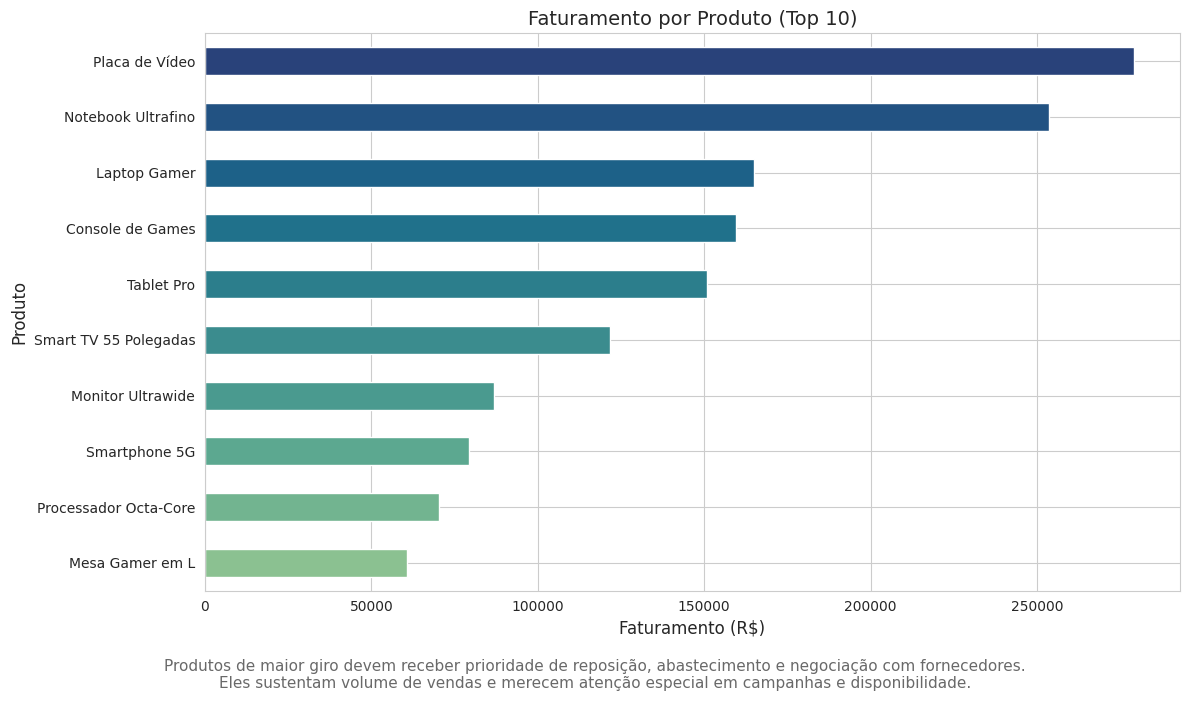

In [730]:
# define um estilo para o grafico
sns.set_style("whitegrid")

# define uma nova figura
plt.figure(figsize = (12, 7))

# define grafico de barras horizontais
top_10_produtos_com_maior_faturamento.sort_values(ascending=True).plot(kind = "barh", color = sns.color_palette("crest", 10))

# define titulo e labels
plt.title("Faturamento por Produto (Top 10)", fontsize = 14)
plt.xlabel("Faturamento (R$)", fontsize = 12)
plt.ylabel("Produto", fontsize = 12)

# interpreta o grafico sem poluir a visualizacao
plt.figtext(0.5, 0.01,
            "Produtos de maior giro devem receber prioridade de reposição, abastecimento e negociação com fornecedores.\n"
            "Eles sustentam volume de vendas e merecem atenção especial em campanhas e disponibilidade.",
            ha="center", fontsize=11, color="dimgray")

# exibe o grafico
plt.tight_layout(rect = [0, 0.06, 1, 1])
plt.show()

## 7. Análise 02 - Faturamento Mensal
Qual foi o faturamento mensal?

In [731]:
# exibe os dados
df_vendas[["data_pedido", "faturamento"]].head()

,data_pedido,faturamento
0,2025-07-05 02:33:27,4250.0
1,2025-12-19 19:17:46,190.0
2,2025-11-16 07:47:20,1480.0
3,2025-06-24 21:51:13,860.0
4,2025-11-04 23:10:59,95.0


In [732]:
# define a coluna "mes" para o agrupamento mensal
df_vendas["mes"] = df_vendas["data_pedido"].dt.to_period("M")

# exibe os dados
df_vendas[["data_pedido", "mes", "faturamento"]].head()

,data_pedido,mes,faturamento
0,2025-07-05 02:33:27,2025-07,4250.0
1,2025-12-19 19:17:46,2025-12,190.0
2,2025-11-16 07:47:20,2025-11,1480.0
3,2025-06-24 21:51:13,2025-06,860.0
4,2025-11-04 23:10:59,2025-11,95.0


In [733]:
# agrupa por mes e soma o faturamento
faturamento_mensal = df_vendas.groupby("mes")["faturamento"].sum()

# exibe o resultado
faturamento_mensal

mes
2025-04    215099.18
2025-05    249423.00
2025-06    194909.83
2025-07    169883.70
2025-08    169106.41
2025-09    186183.54
2025-10    123417.20
2025-11    225685.52
2025-12    223503.12
2026-01    187864.82
2026-02    182019.09
2026-03    191327.39
Freq: M, Name: faturamento, dtype: float64

In [734]:
# exibe o tipo de dado do index deste dataframe
faturamento_mensal.index

PeriodIndex(['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09',
             '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03'],
            dtype='period[M]', name='mes')

In [735]:
# converte o indice para string para facilitar a plotagem do grafico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [736]:
# formata para duas casas decimais
faturamento_mensal.map("R$ {:,.2f}".format)

# exibe o resultado
faturamento_mensal

# formata para o padrao moeda do brasil
# import locale

#locale.setlocale(locale.LC_ALL, "pt_BR.UTF-8")

#faturamento_mensal_formatado = faturamento_mensal.map(
#    lambda x: locale.currency(x, grouping=True)
#)

# exibe o resultado
#faturamento_mensal_formatado

mes
2025-04    215099.18
2025-05    249423.00
2025-06    194909.83
2025-07    169883.70
2025-08    169106.41
2025-09    186183.54
2025-10    123417.20
2025-11    225685.52
2025-12    223503.12
2026-01    187864.82
2026-02    182019.09
2026-03    191327.39
Name: faturamento, dtype: float64

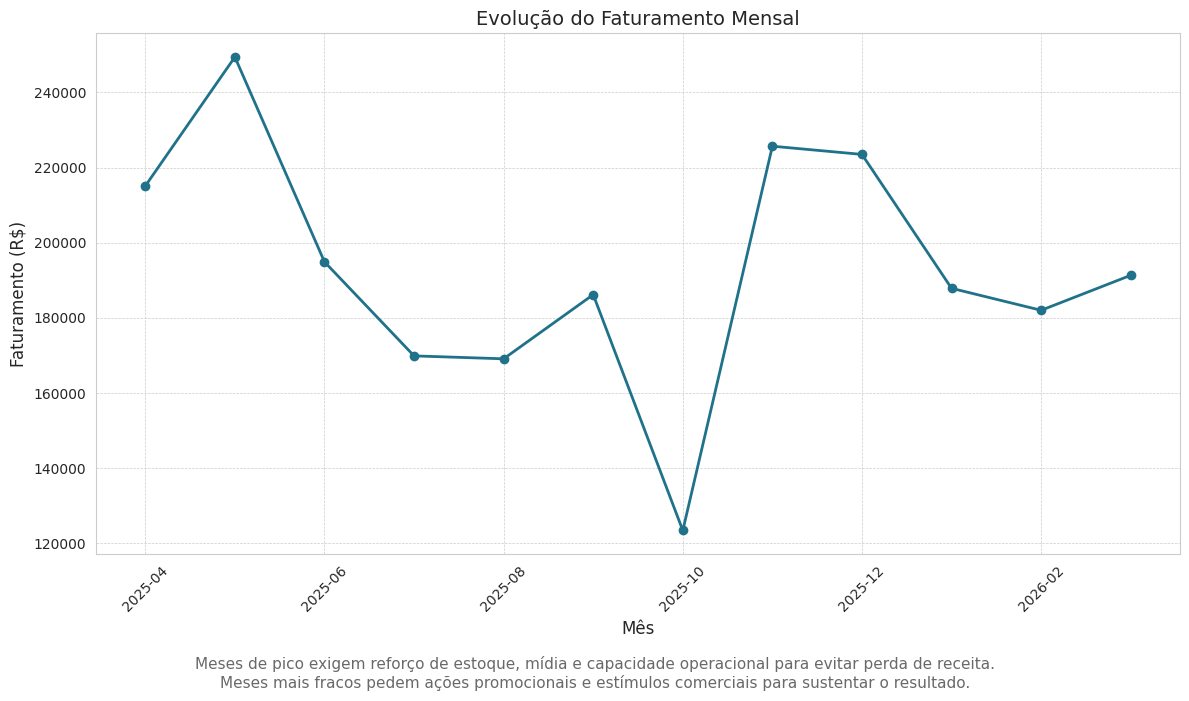

In [737]:
# define uma nova figura
plt.figure(figsize = (12, 7))

# plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = "line", marker = "o", linestyle = "-", linewidth = 2, color = sns.color_palette("crest", 7)[4])

# define o titulo do grafico
plt.title("Evolução do Faturamento Mensal", fontsize = 14)

# define o rotulo do eixo x
plt.xlabel("Mês", fontsize = 12)

# define o rotulo do eixo y
plt.ylabel("Faturamento (R$)", fontsize = 12)

# rotaciona o rotulo do eixo x para melhor visualizacao
plt.xticks(rotation = 45)

# adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# interpreta o grafico sem poluir a visualizacao
plt.figtext(0.5, 0.01,
            "Meses de pico exigem reforço de estoque, mídia e capacidade operacional para evitar perda de receita.\n"
            "Meses mais fracos pedem ações promocionais e estímulos comerciais para sustentar o resultado.",
            ha = 'center', fontsize = 11, color = 'dimgray')

# ajusta automaticamente os elementos para evitar sobreposicao
plt.tight_layout(rect = [0, 0.06, 1, 1])

# exibe o grafico
plt.show()

## 8. Análise 03 - Faturamento por Estado
Qual o faturamento total por estado?

In [738]:
# agrupa por estado e soma o faturamento
faturamento_por_estado = df_vendas.groupby("estado")["faturamento"].sum().sort_values(ascending = False)

In [739]:
# formata para duas casas decimais
faturamento_por_estado.map('R$ {:,.2f}'.format)

estado
SP    R$ 480,731.45
RJ    R$ 237,917.62
MG    R$ 182,652.04
BA    R$ 165,544.15
PA    R$ 126,662.58
RS    R$ 119,652.50
GO     R$ 98,901.60
ES     R$ 98,710.00
PB     R$ 95,100.00
PE     R$ 90,811.27
PR     R$ 82,901.36
RO     R$ 79,450.00
CE     R$ 58,765.26
SE     R$ 55,148.54
AM     R$ 54,880.14
SC     R$ 51,078.51
MA     R$ 45,698.87
MT     R$ 42,729.12
AL     R$ 40,275.44
DF     R$ 35,739.40
RN     R$ 25,156.89
MS     R$ 21,563.52
AP     R$ 15,014.52
PI     R$ 13,338.02
Name: faturamento, dtype: str

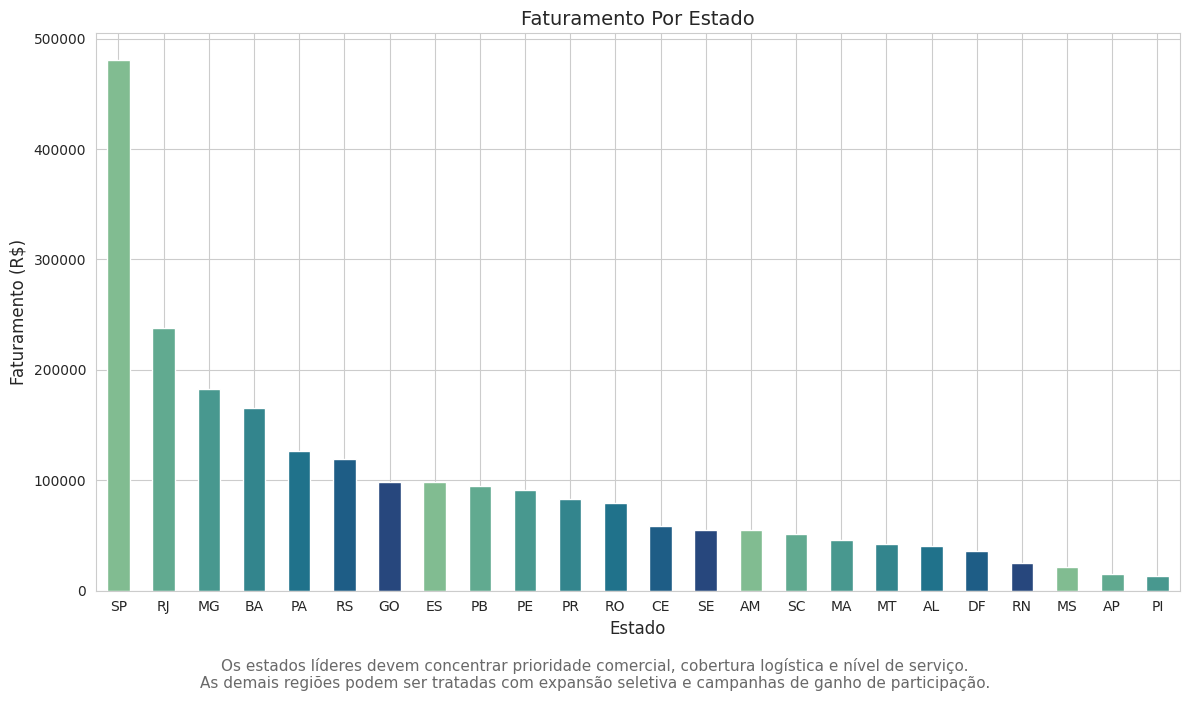

In [740]:
# define uma nova figura
plt.figure(figsize = (12, 7))

# plota os dados de faturamento por estado em formato de grafico de barras
# usando a paleta de cores "rocket" do Seaborn
faturamento_por_estado.plot(kind = 'bar', color = sns.color_palette("crest", 7))

# define o titulo do grafico
plt.title('Faturamento Por Estado', fontsize = 14)

# define o rotulo do eixo x
plt.xlabel('Estado', fontsize = 12)

# define o rotulo do eixo y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# mantem o rotulo do eixo x na horizontal (sem rotacao)
plt.xticks(rotation = 0)

# interpreta o grafico sem poluir a visualizacao
plt.figtext(0.5, 0.01,
            "Os estados líderes devem concentrar prioridade comercial, cobertura logística e nível de serviço.\n"
            "As demais regiões podem ser tratadas com expansão seletiva e campanhas de ganho de participação.",
            ha = 'center', fontsize = 11, color = 'dimgray')

# ajusta automaticamente os elementos do grafico para evitar sobreposicao
plt.tight_layout(rect = [0, 0.06, 1, 1])

# exibe o grafico
plt.show()

## 9. Análise 04 - Faturamento por Categoria
Qual o faturamento total por categoria?

In [741]:
# agrupa por categoria e soma o faturamento
faturamento_por_categoria = df_vendas.groupby("categoria")["faturamento"].sum().sort_values(ascending = False)

In [742]:
# formata para duas casas decimais
faturamento_por_categoria.map('R$ {:,.2f}'.format)

categoria
Eletrônicos         R$ 1,114,750.00
Hardware              R$ 555,960.00
Móveis                R$ 218,450.00
Periféricos           R$ 201,409.69
Acessórios            R$ 112,303.11
Casa Inteligente       R$ 60,635.00
Redes                  R$ 54,915.00
Name: faturamento, dtype: str

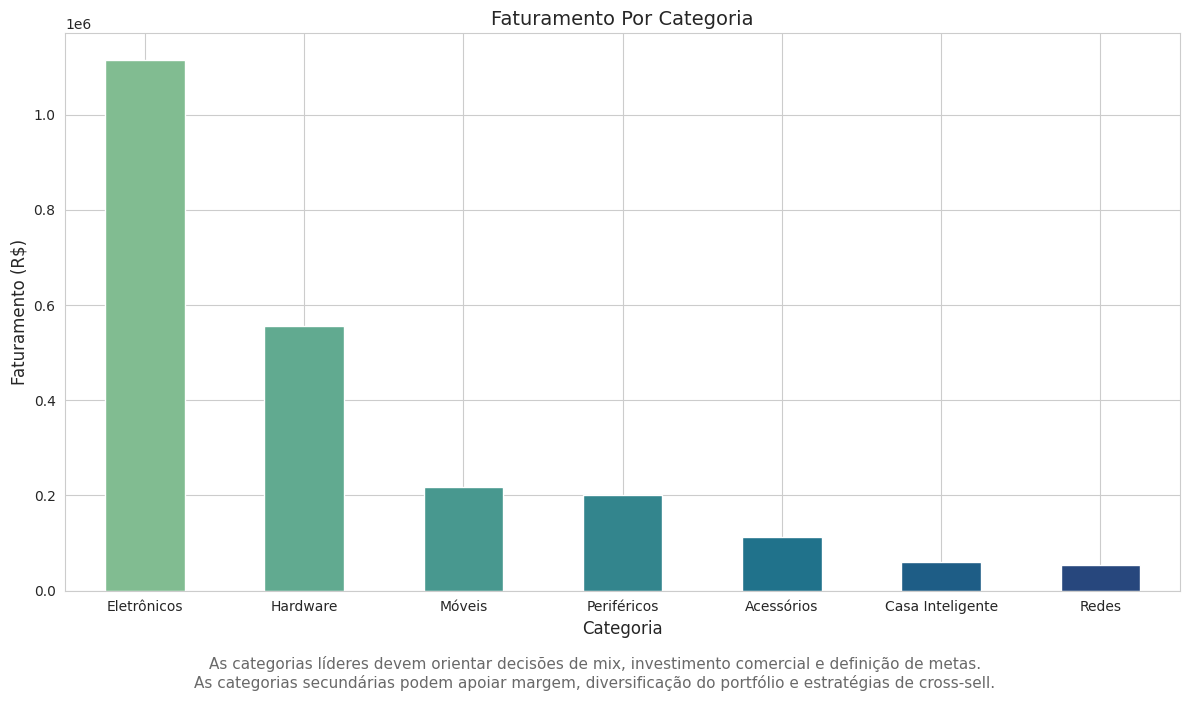

In [743]:
# define uma nova figura
plt.figure(figsize = (12, 7))

# plota os dados de faturamento por categoria em formato de grafico de barras
faturamento_por_categoria.plot(kind = 'bar', color = sns.color_palette("crest", 7))

# define o titulo do grafico
plt.title('Faturamento Por Categoria', fontsize = 14)

# define o rotulo do eixo x
plt.xlabel('Categoria', fontsize = 12)

# define o rotulo do eixo y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# mantem o rotulo do eixo x na horizontal (sem rotacao)
plt.xticks(rotation = 0)

# interpreta o grafico sem poluir a visualizacao
plt.figtext(0.5, 0.01,
            "As categorias líderes devem orientar decisões de mix, investimento comercial e definição de metas.\n"
            "As categorias secundárias podem apoiar margem, diversificação do portfólio e estratégias de cross-sell.",
            ha = 'center', fontsize = 11, color = 'dimgray')

# ajusta automaticamente os elementos do grafico para evitar sobreposicao
plt.tight_layout(rect = [0, 0.06, 1, 1])

# exibe o grafico
plt.show()

## 10. Conclusão e Entrega do Resultado

Nos últimos 12 meses completos analisados, o negócio gerou faturamento de R$ 2.318.422,80, com ticket médio de R$ 4.636,85 por pedido. O principal sinal para a tomada de decisão é a concentração da receita em categorias e produtos de maior valor, o que reforça a necessidade de proteger disponibilidade, margem e execução comercial nesses grupos.

Do ponto de vista da gestão, Eletrônicos respondeu por 48,08% do faturamento total e Hardware por 23,98%, mostrando que essas duas frentes sustentam a maior parte do resultado. Em produtos, Placa de Vídeo, Notebook Ultrafino, Laptop Gamer, Console de Games e Tablet Pro lideraram a geração de receita. A implicação prática é clara: essas linhas devem receber prioridade em negociação com fornecedores, política comercial, cobertura de estoque e definição de metas.

Para marketing, a leitura regional mostra maior peso de São Paulo, com 20,74% da receita, seguido por Rio de Janeiro, Minas Gerais, Bahia e Pará. Isso sugere concentrar campanhas, mídia e ações promocionais nas praças com maior retorno potencial, sem perder de vista oportunidades de expansão nos mercados logo abaixo do topo. A combinação entre categorias de maior valor e estados mais relevantes deve orientar segmentação, calendário promocional e distribuição de verba.

Para logística e operações, o recorte geográfico e a concentração de receita indicam onde a execução precisa ser mais confiável. Os estados líderes devem ser tratados como prioridade para abastecimento, reposição e nível de serviço, especialmente nos períodos de maior demanda. No calendário mensal, maio, novembro e dezembro foram os meses de melhor desempenho, enquanto julho, agosto e outubro exigem leitura mais cuidadosa para ações de estímulo comercial e melhor balanceamento operacional.

Como encaminhamento executivo, a recomendação é atuar em quatro frentes: garantir disponibilidade dos produtos que mais geram receita, fortalecer presença comercial nas categorias líderes, direcionar investimentos de marketing para os estados de maior retorno e preparar a operação para responder melhor aos meses de pico. Com isso, a empresa melhora sua capacidade de crescer com mais foco, maior eficiência e melhor alocação de recursos.